# Netzwerkdaten-Analyse & Klassifikation von Angriffen
Ziel dieses Projekts ist die Entwicklung eines Klassifikationsmodells zur Erkennung von Angriffen im Netzwerkverkehr auf Basis maschinellen Lernens. Als Datenbasis dient der CIC IoT-DIAD 2024 Datensatz des Canadian Institute for Cybersecurity, der simulierten Netzwerktraffic aus 33 Angriffsszenarien in einem Netzwerk mit 105 IoT-Geräten umfasst. Im Fokus dieses Modells stehen dabei gezielt Brute-Force-Angriffe.

Aus dem Datensatz wurden flowbasierte Features extrahiert, darunter Paketanzahl, Datenvolumen, Verbindungsdauer sowie TCP-Flag-Counts, da diese Kommunikationsmuster unabhängig vom übertragenen Inhalt abbilden. Da der Datensatz stark unausgewogen ist (ca. 95,7 % benigner Traffic), wird der F1-Score als primäre Bewertungsmetrik verwendet.

Das Notebook gliedert sich in folgende Abschnitte: explorative Datenanalyse (EDA), Vorverarbeitung und Feature-Auswahl, Training und Vergleich mehrerer Klassifikatoren (Random Forest, Decision Tree, LightGBM, Gradient Boosting), gefolgt von einer systematischen Optimierung der Preprocessing-Strategien sowie einer Hyperparameter-Tuning-Phase mittels BayesSearchCV. Abschließend werden die beiden besten Modelle, RandomForestClassifier und LGBMClassifier, verglichen und bewertet.

Quellen: https://www.unb.ca/cic/datasets/iot-diad-2024.html 


In [1]:
# 1. Bibliotheken laden
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt


In [ ]:
#Laden der Datensätze
#Benign
benign = pd.read_csv("data/BenignTraffic.pcap_Flow.csv")
benign['Label'] = 'benign'

benign1 = pd.read_csv("data/BenignTraffic2.pcap_Flow.csv")
benign1['Label'] = 'benign'

#Angriffe
brute_force = pd.read_csv("data/DictionaryBruteForce.pcap_Flow.csv")
brute_force['Label'] = 'anomaly'

#Zusammenführen der Datensätze
df = pd.concat([benign, benign1, brute_force,], ignore_index=True)#dns_spoofing, ddos_attack


Für das Training des MVPs wurden aus dem CIC IoT-DIAD 2024 Datensatz gezielt die folgenden Features ausgewählt: Flow Duration, Total Fwd Packet, Total Bwd packets, Total Length of Fwd Packet, Total Length of Bwd Packet, Flow IAT Mean, Flow Bytes/s, SYN Flag Count, ACK Flag Count, FIN Flag Count, sowie das Label zur Klassifikation.   
Die Flow-basierten Features wurden bewusst gewählt, da sie Kommunikationsmuster (z. B. Dauer, Datenvolumen, Paketanzahl und -richtung) unabhängig vom übertragenen Inhalt erfassen. Das ist besonders wichtig, um auch neuartige oder Zero-Day-Angriffe zu erkennen, die nicht über bekannte Protokolle erfolgen. Da die Relevanz von Merkmalen eine Momentaufnahme darstellt, sollten diese regelmäßig überprüft und angepasst werden.

| Feature                    | Beschreibung                                                                                         |
|---------------------------|------------------------------------------------------------------------------------------------------|
| **Flow Duration**         | Dauer der gesamten Verbindung (Flow)                                                                 |
| **Total Fwd Packet**      | Anzahl der Pakete, die vom Quell- zum Zielgerät gesendet wurden                                     |
| **Total Bwd packets**     | Anzahl der Pakete, die vom Ziel- zurück zum Quellgerät gesendet wurden                              |
| **Total Length of Fwd Packet** | Gesamte Datenmenge (in Bytes) der Pakete in Vorwärtsrichtung                              |
| **Total Length of Bwd Packet** | Gesamte Datenmenge (in Bytes) der Pakete in Rückwärtsrichtung                           |
| **Flow IAT Mean**         | Durchschnittliche Zeit zwischen zwei Paketen innerhalb des Flows                                    |
| **Flow Bytes/s**          | Durchschnittliche Übertragungsrate in Bytes pro Sekunde                                             |
| **SYN Flag Count**        | Anzahl der Pakete mit gesetztem SYN-Flag (Verbindungsaufbau in TCP)                                 |
| **ACK Flag Count**        | Anzahl der Pakete mit gesetztem ACK-Flag (Bestätigungspakete in TCP)                                |
| **FIN Flag Count**        | Anzahl der Pakete mit gesetztem FIN-Flag (Verbindungsbeendigung in TCP)                             |
| **Label**                 | Klassifikationsfeature                                                                               |  


In [3]:
#Auswahl der Feature
data_useful = df[['Flow Duration', 'Total Fwd Packet',
       'Total Length of Fwd Packet', 'Total Length of Bwd Packet',"Label","Flow IAT Mean","Flow Bytes/s",'SYN Flag Count', 'ACK Flag Count', 'FIN Flag Count']]

In [4]:
data_useful = data_useful.replace([np.inf, -np.inf], np.nan)

In [5]:
data_useful = data_useful.sample(frac=1, random_state=42).reset_index(drop=True)
print("Label-Verteilung (gesamt):")
print(data_useful["Label"].value_counts(normalize=True))


Label-Verteilung (gesamt):
Label
benign     0.957335
anomaly    0.042665
Name: proportion, dtype: float64


Der verwendete Datensatz zeigt eine starke Unausgewogenheit zwischen benignem und anomalem Netzwerkverkehr: Etwa 95,7 % der Verbindungen sind unauffällig, während nur rund 4,3 % als Anomalien klassifiziert sind. Diese Verteilung wirkt sich deutlich auf die Modellbewertung aus. Eine hohe Accuracy ist in diesem Szenario wenig aussagekräftig, da sie hauptsächlich durch die dominierende Mehrheitsklasse beeinflusst wird. Deshalb liegt der Fokus auf dem F1-Score, der Precision und Recall besser miteinander ausbalanciert und sich besonders bei unausgeglichenen Daten bewährt.

Die bewusste Wahl eines unausgeglichenen Datensatzes dient der realistischen Abbildung tatsächlicher Netzwerkbedingungen. Angriffe sind in der Praxis selten, weshalb ein künstlich ausgewogener Datensatz (z. B. 50 % Angriffe) das Modell zu empfindlich machen würde – mit dem Risiko häufiger Fehlalarme. Um die Analyse gezielt zu fokussieren, wurden ausschließlich Brute-Force-Angriffe berücksichtigt.

# EDA

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

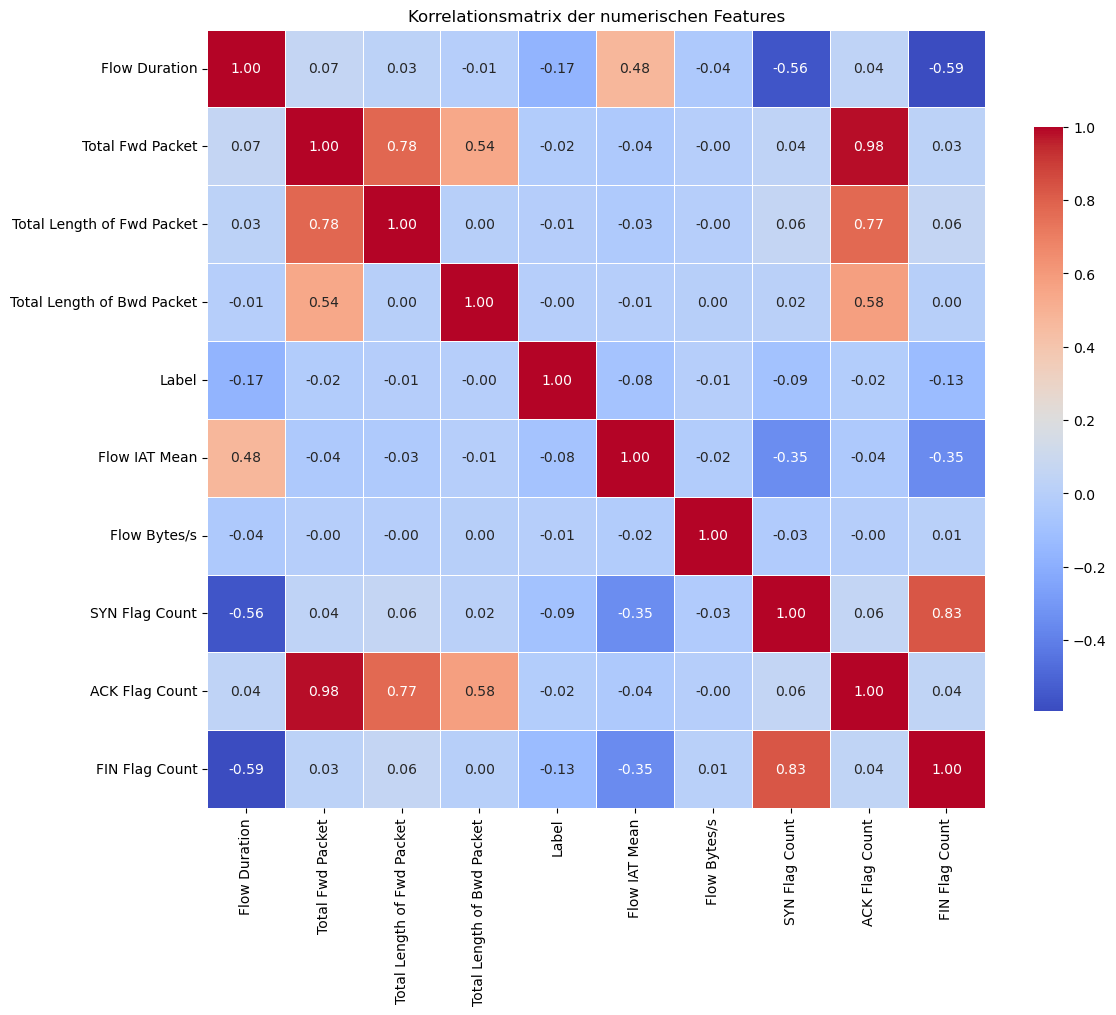

In [7]:
# Label numerisch kodieren
data_corr = data_useful.copy()
data_corr['Label'] = data_corr['Label'].map({'benign': 0, 'anomaly': 1})

# Korrelation berechnen
corr_matrix = data_corr.corr(numeric_only=True)

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True,
            cbar_kws={"shrink": .75}, linewidths=0.5)
plt.title("Korrelationsmatrix der numerischen Features")
plt.tight_layout()
plt.show()


Ein zentrales Ergebnis ist die starke Korrelation (r = 0,98) zwischen der Anzahl weitergeleiteter Pakete (Total Fwd Packet) und dem ACK-Flag Count. Diese Beziehung legt nahe, dass reguläre Verbindungen mit vielen Datenpaketen erwartungsgemäß zahlreiche Bestätigungen (ACKs) erzeugen. Auch die Korrelation zwischen Total Fwd Packet und Total Length of Fwd Packet (r = 0,78) verdeutlicht diesen Zusammenhang zwischen Paketanzahl und übertragenem Datenvolumen.

Auffällig ist ebenfalls die positive Korrelation zwischen dem Total Length of Bwd Packet und dem ACK-Flag Count (r = 0,58). Das spricht dafür, dass Verbindungen mit umfangreichem Rückverkehr ebenfalls durch viele Bestätigungspakete gekennzeichnet sind – ein Muster, das typisch für normale, bidirektionale Kommunikation ist.

Im Kontrast dazu stehen die negativen Korrelationen zwischen Flow Duration und den Flag-Zählern für SYN (r = −0,56) und FIN (r = −0,59). Diese deuten darauf hin, dass Verbindungen mit kurzen Laufzeiten häufiger mit SYN- oder FIN-Flags verknüpft sind – ein mögliches Indiz für Brute-Force-Versuche, bei denen Verbindungen rasch und in großer Zahl aufgebaut und wieder beendet werden.

Die Zielvariable Label, die normale und anomale Verbindungen unterscheidet, zeigt nur schwache Korrelationen mit den übrigen Merkmalen. Die höchsten Beträge (r ≈ ±0,17) treten bei Flow Duration und Flow IAT Mean auf. Dies bestätigt, dass keines der betrachteten Einzelmerkmale für sich genommen eine starke Trennschärfe zwischen normalen und bösartigen Flows bietet.

In [8]:
# Plot-Stil
sns.set(style="whitegrid", palette="pastel")

# Liste der Features für die Plots
features_to_plot = [
    'Flow Duration', 'Total Fwd Packet',
    'Total Length of Fwd Packet', 'Total Length of Bwd Packet',
    'Flow IAT Mean', 'Flow Bytes/s',
    'SYN Flag Count', 'ACK Flag Count', 'FIN Flag Count'
]

/tmp/ipykernel_1789/3997570870.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data_useful, x='Label', palette='Set2')


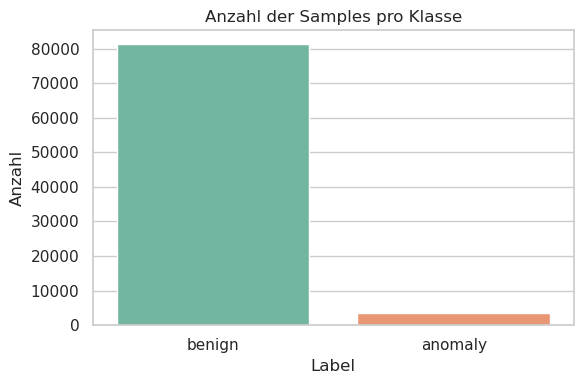

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=data_useful, x='Label', palette='Set2')
plt.title("Anzahl der Samples pro Klasse")
plt.xlabel("Label")
plt.ylabel("Anzahl")
plt.tight_layout()
plt.show()

Wie bereits erwähnt, handelt es sich um einen unausgeglichenen Datensatz, der die reale Verteilung von normalem und anomalem Netzwerkverkehr widerspiegelt.

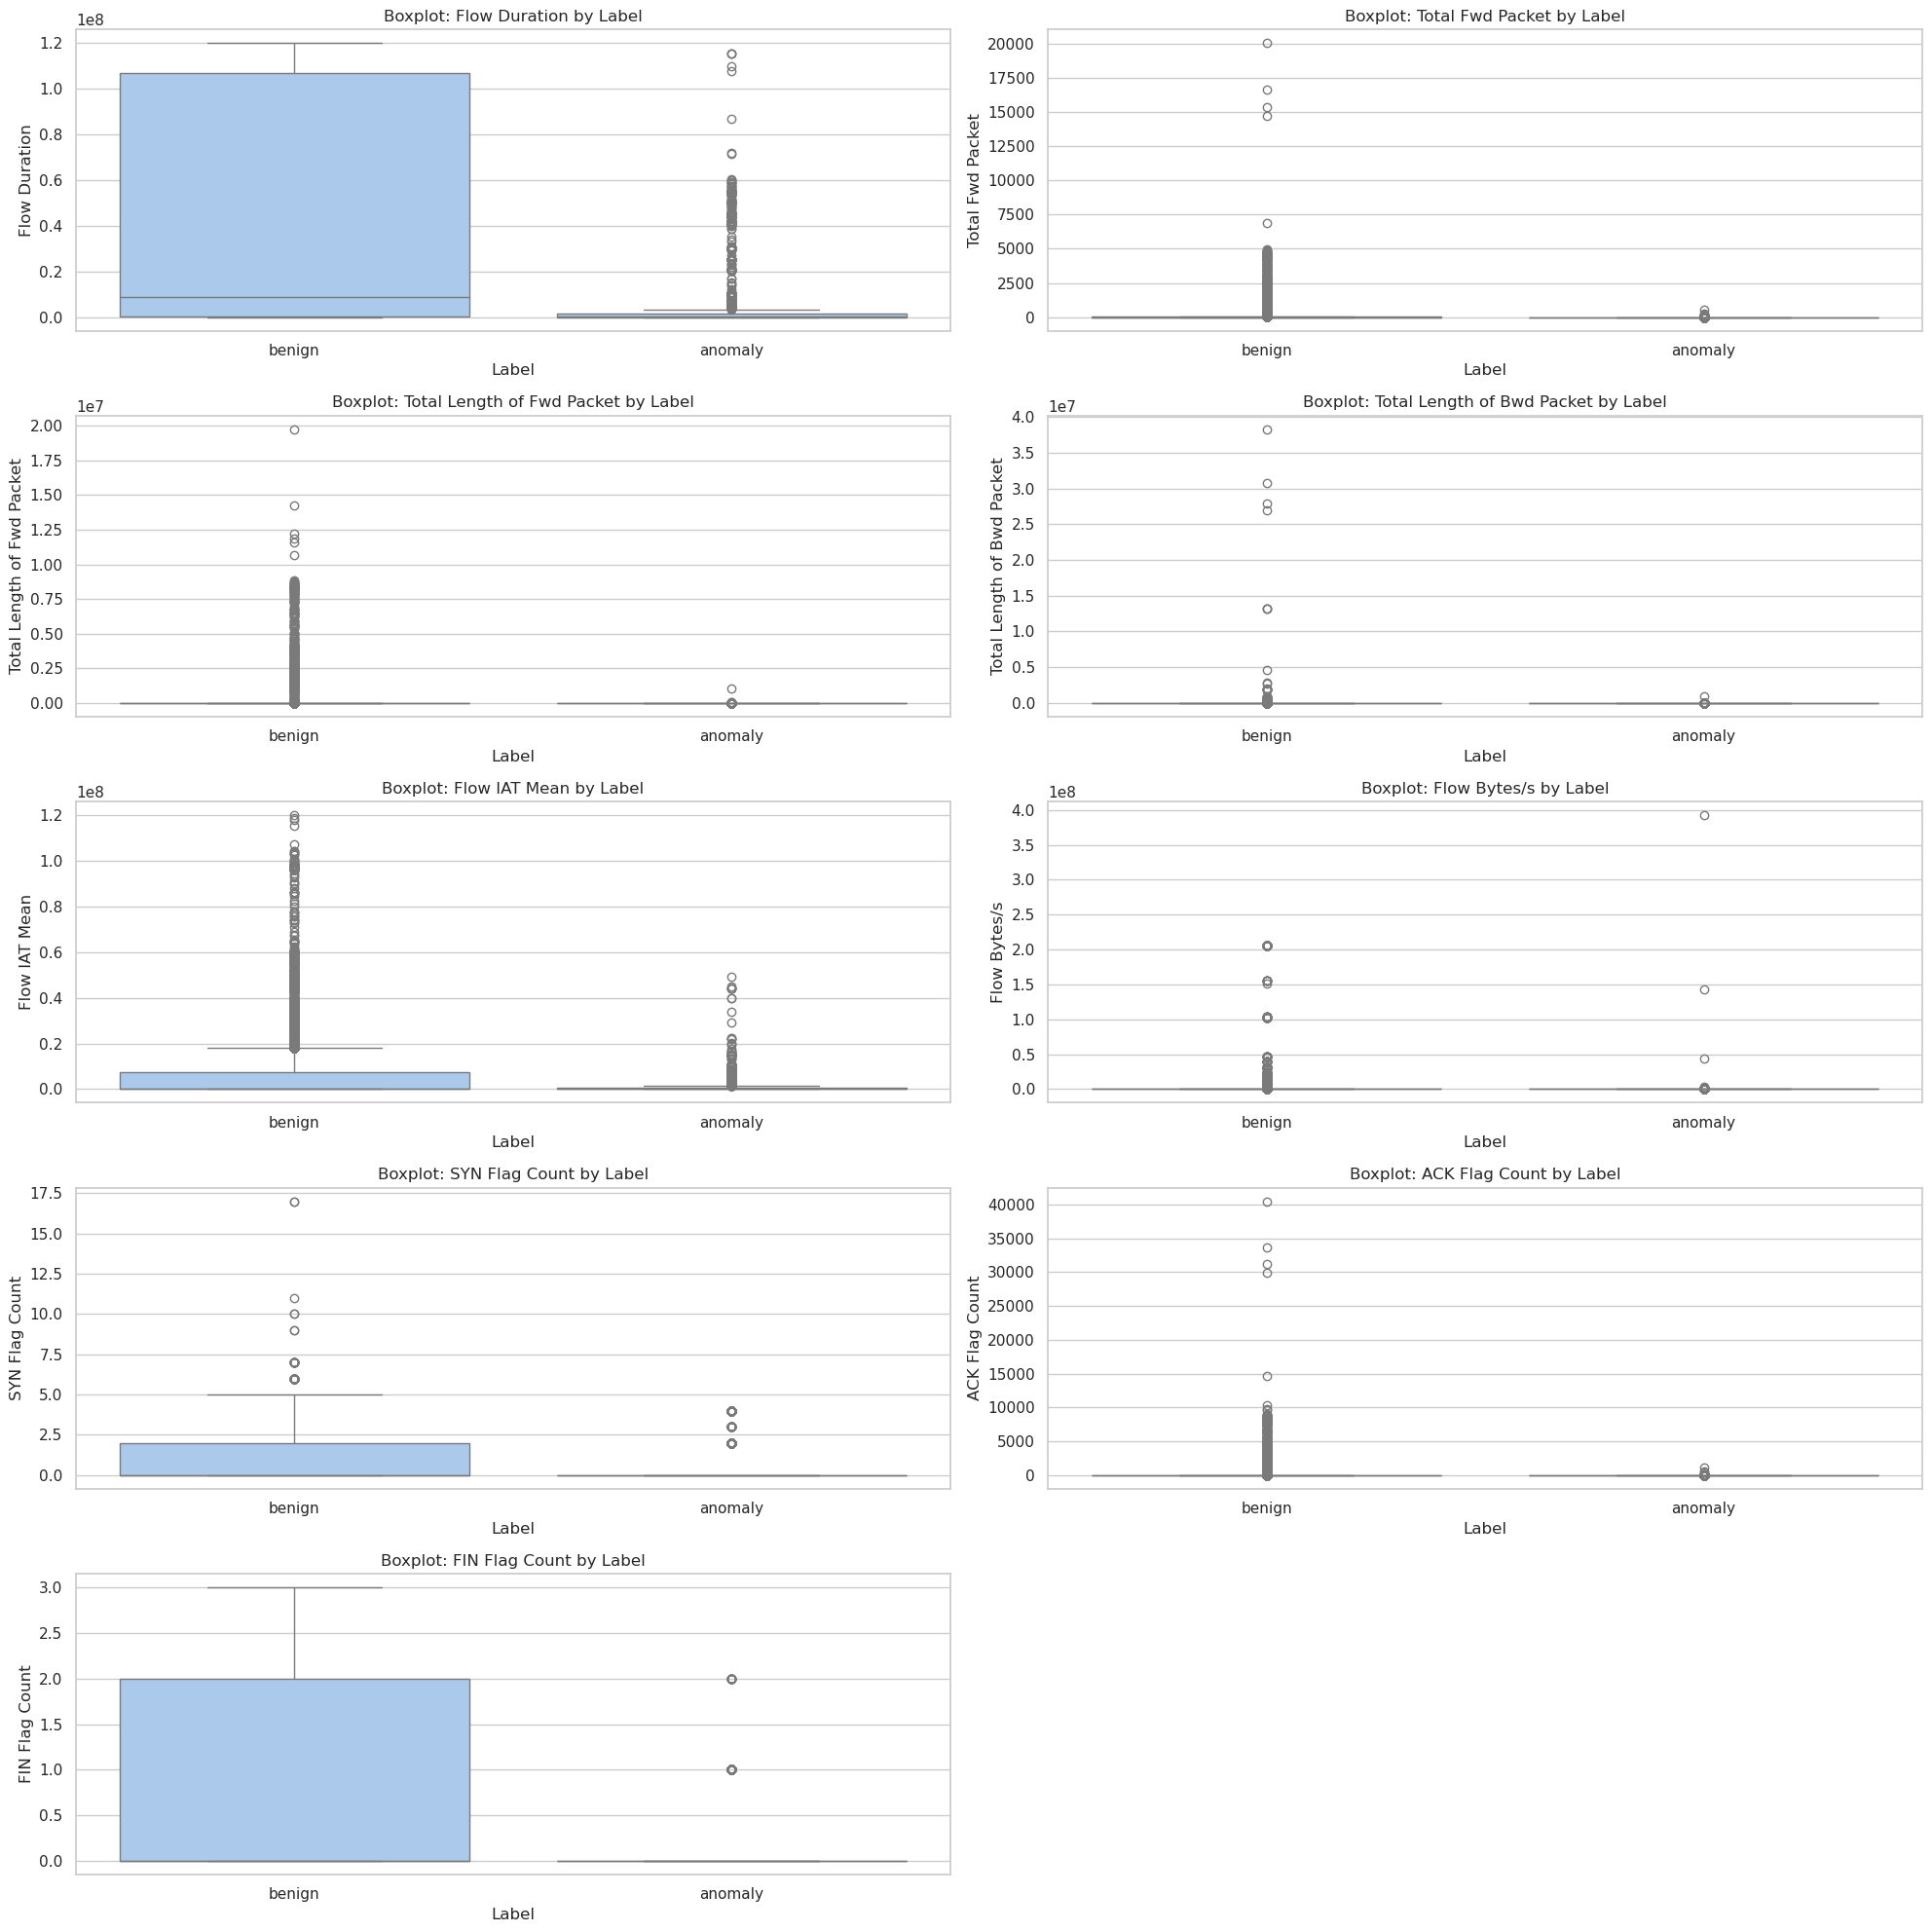

In [10]:
# 1. Boxplots pro Feature, gruppiert nach Label
plt.figure(figsize=(20, 20))
for i, feature in enumerate(features_to_plot):
    plt.subplot(5, 2, i+1)
    sns.boxplot(data=data_useful, x='Label', y=feature)
    plt.title(f"Boxplot: {feature} by Label")
    plt.tight_layout()
plt.show()

## Interpretation Boxplots
Ein zentrales Muster der Boxplots ist die deutlich höhere Varianz benignen Netzwerkverkehrs in nahezu allen betrachteten Merkmalen. Dies spiegelt die natürliche Heterogenität legitimer Verbindungen wider – mit einer breiten Streuung und zahlreichen Ausreißern. Anomale Verbindungen hingegen konzentrieren sich stark im unteren Wertebereich, was auf standardisierte, häufig automatisierte Angriffsmuster hinweist.

SYN-, FIN- und ACK-Flags: Während benignes Verhalten eine breite Spannweite aufweist – insbesondere beim ACK-Flag Count mit Extremwerten bis über 40.000 – sind Anomalien deutlich begrenzter (unter 5000). Dies legt nahe, dass Angriffe in der Regel keine ausgeprägte Bestätigungskommunikation aufbauen und in sehr kurzen Sessions ablaufen.

Flow Duration und Flow IAT Mean: Benigne Verbindungen weisen wesentlich längere Sitzungsdauern und Zwischenankunftszeiten auf. Die stark komprimierten Werte der Anomalien lassen auf kurzlebige, nicht-persistente Verbindungen schließen – typisch für Brute-Force- oder Reconnaissance-Aktivitäten.

Flow Bytes/s: Interessanterweise zeigen einige anomale Verbindungen extreme Werte in der Datenrate, was auf kurze, intensive Übertragungen hinweist. Die meisten benignen Flows bewegen sich dagegen im unteren bis mittleren Bereich. Diese Ausreißer könnten auf gezielte Datenexfiltration oder DDoS-Komponenten hinweisen.


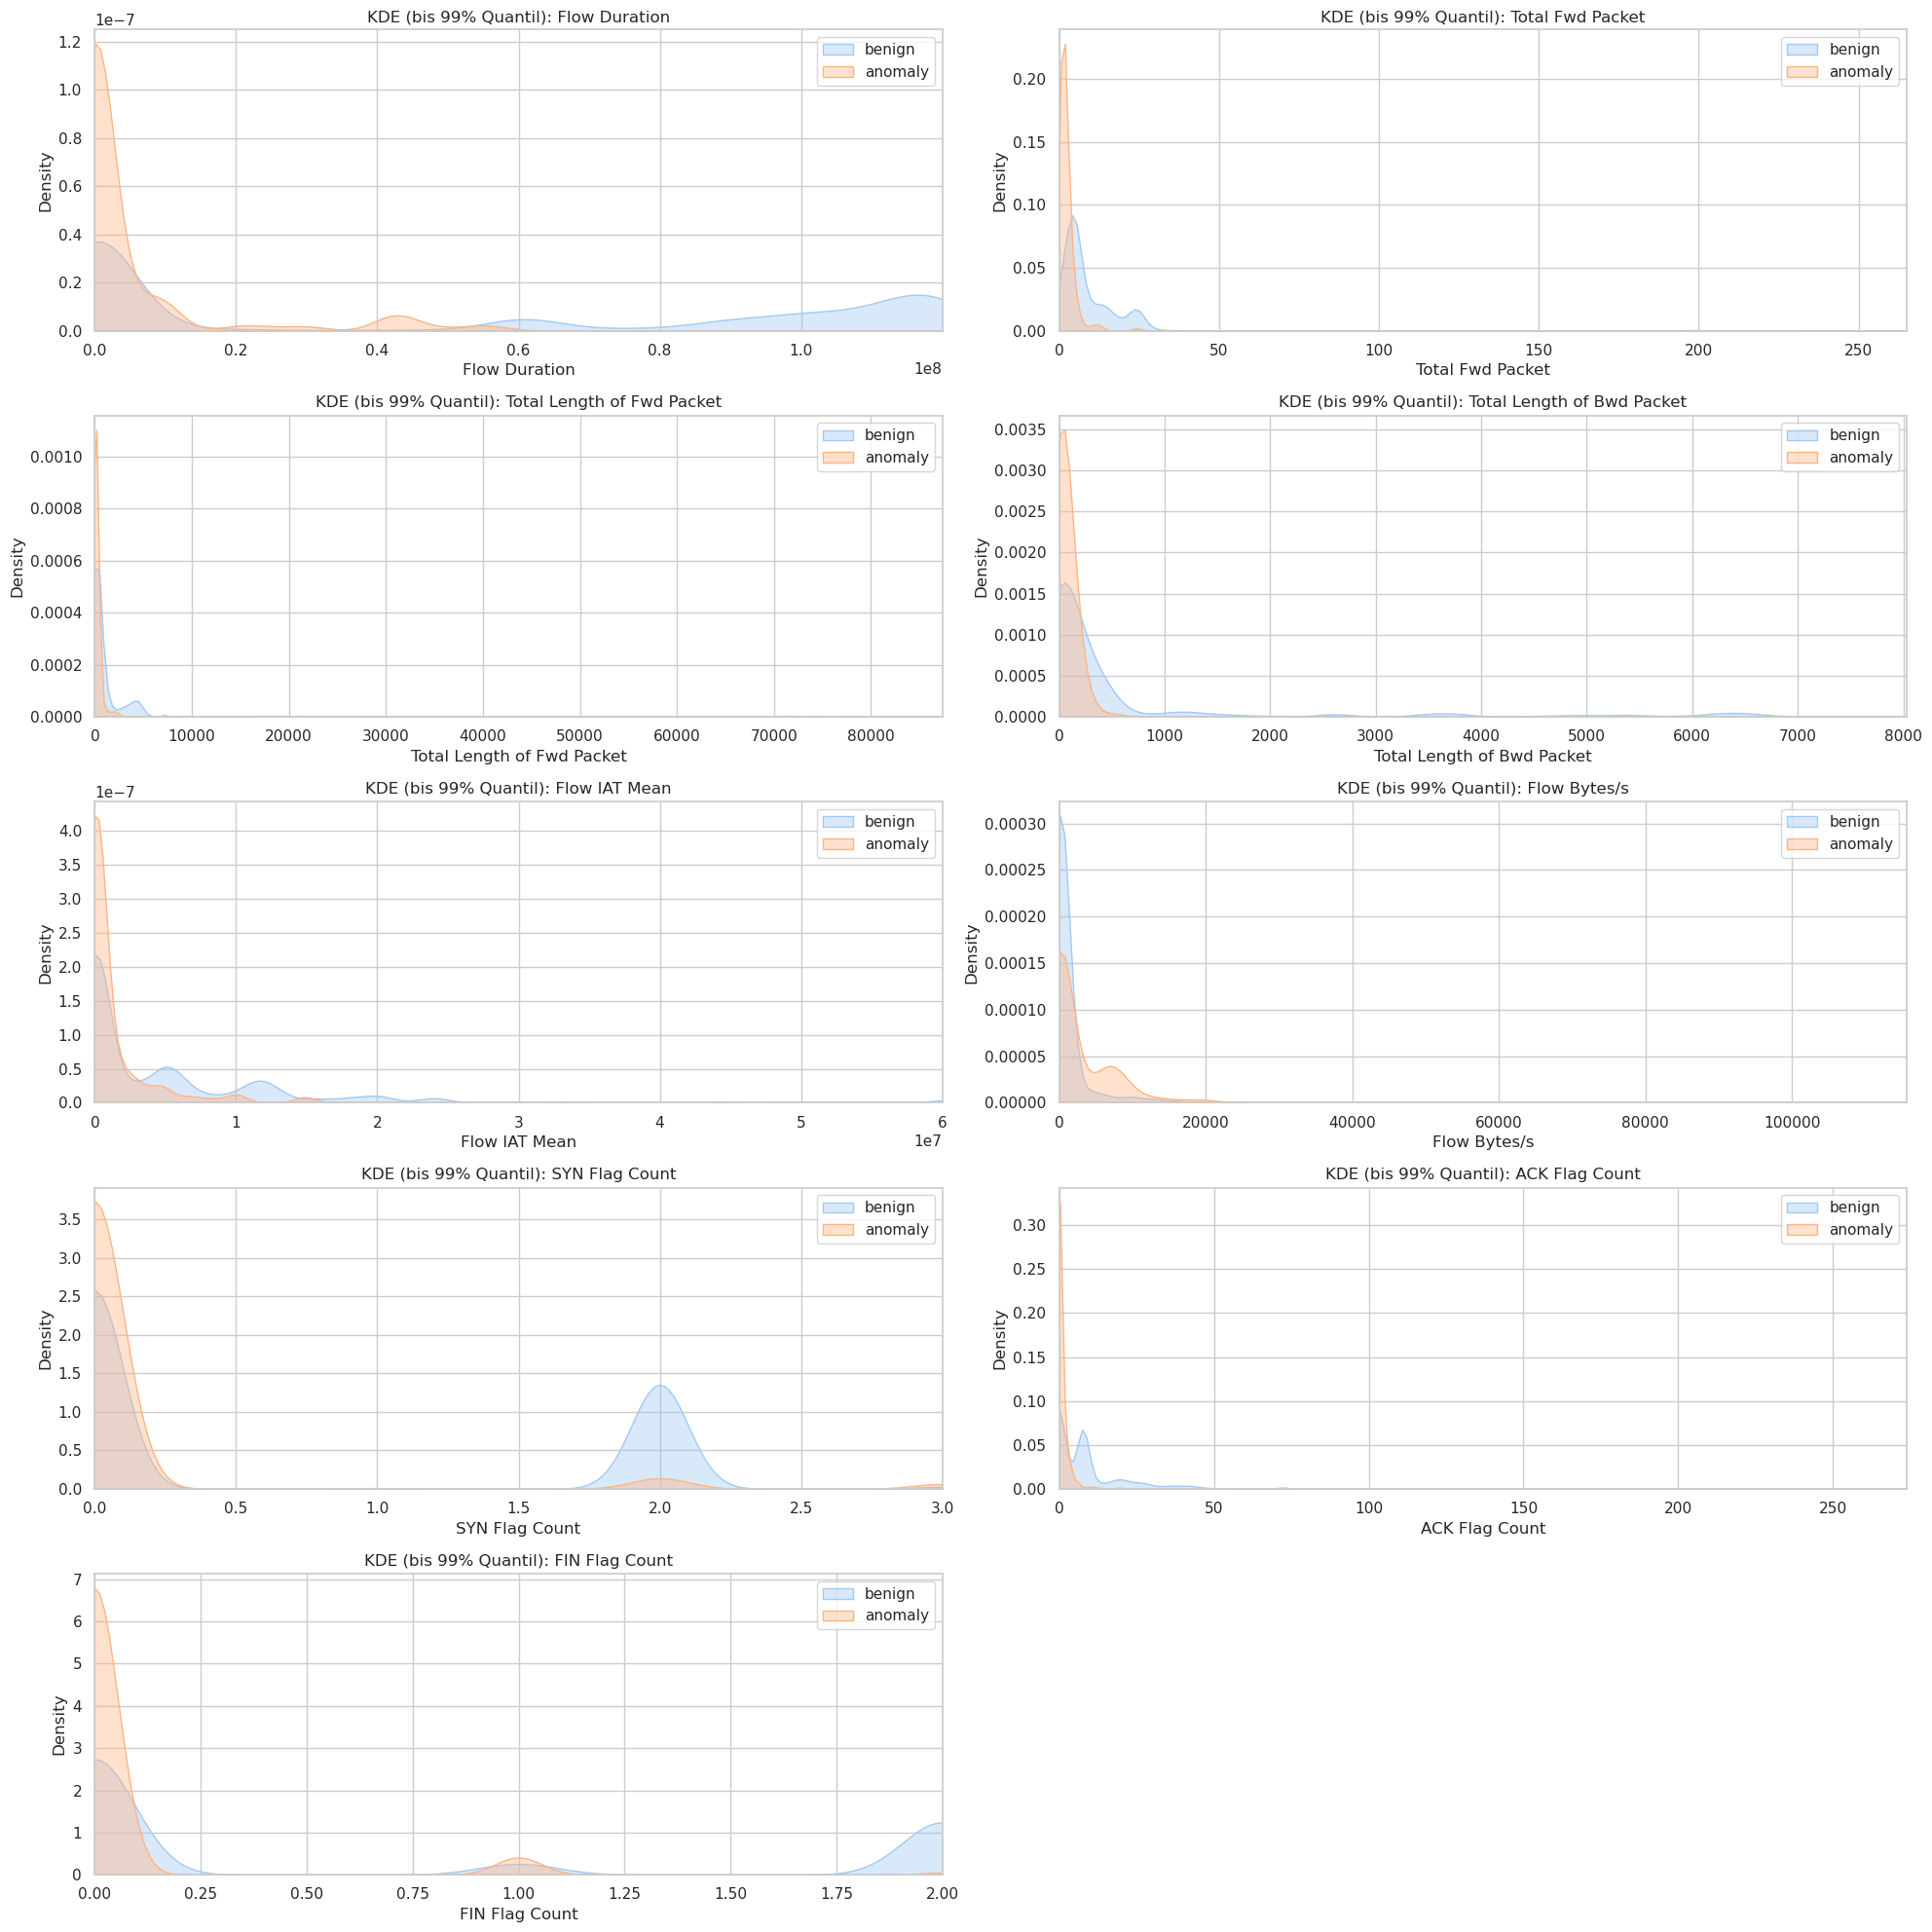

In [11]:
plt.figure(figsize=(20, 20))
for i, feature in enumerate(features_to_plot):
    plt.subplot(5, 2, i+1)
    
    # 99. Perzentil für sinnvolle Achsenskalierung
    x_max = data_useful[feature].quantile(0.99)
    
    for label in data_useful['Label'].unique():
        subset = data_useful[data_useful['Label'] == label]
        sns.kdeplot(data=subset[feature][subset[feature] <= x_max],
                    label=label, fill=True, alpha=0.4)
    
    plt.title(f"KDE (bis 99% Quantil): {feature}")#für bessere Darstellung, Ausreißer sind bereits im Boxplot zu sehen
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.xlim(0, x_max)  # Setzt explizit die x-Achse
    plt.legend()
    plt.tight_layout()
plt.show()


## Interpretation KDE-Plots
Für die Bessere Darstellung wurden jeweils nur das 99% Quantile dargestellt, dementsprechend fehlen nach oben hinaus Werte. Da aber dennoch die zu demonstrierenden Punkte gezeigt werden können, wurde die Dateverzerrung angewandt. 

Die Dichteverteilungen zeigen deutliche Unterschiede zwischen benignen und anomalen Netzwerkverbindungen. Während benigne Flows typischerweise eine breite Streuung und höhere Wertebereiche aufweisen, konzentrieren sich anomale Verbindungen stark auf niedrige Werte – ein Muster, das auf standardisierte, häufig automatisierte Abläufe hindeutet.

SYN- und FIN-Flag-Zähler: Die Verteilung benignen Verkehrs zeigt Peaks bei höheren Flag-Werten (z. B. SYN ≈ 2), was auf klassische Verbindungsauf- und -abbauten hinweist. Im Gegensatz dazu bleiben anomale Verbindungen nahezu vollständig bei 0, was nahelegt, dass viele Angriffe ohne vollständiges TCP-Handshake-Verfahren ablaufen – ein typisches Verhalten bei Brute-Force- oder Scan-Versuchen.

ACK-Flag Count: Auch bei der Anzahl von ACK-Flags ist ein starker Unterschied sichtbar. Benigne Flows zeigen eine breite, asymmetrische Verteilung mit ausgeprägten rechten Flanken, die auf stabile, mehrstufige Kommunikation mit zahlreichen Bestätigungen hinweisen. Anomale Verbindungen dagegen erzeugen meist nur wenige ACKs, was auf fehlende oder abgebrochene Sitzungen hindeutet.

Flow Duration und IAT Mean: Die Verteilungen dieser Merkmale verdeutlichen, dass benigne Verbindungen deutlich längere Laufzeiten und Inter-Paket-Zeiten aufweisen. Anomale Flows liegen stark komprimiert im unteren Bereich, was wiederum für schnelle, einheitliche Angriffsmuster spricht, wie sie bei systematischen Login-Versuchen oder Netzwerkerkundungen typisch sind.

Gesamtlänge und Anzahl der Pakete (Fwd/Bwd): Die Datenmenge und Paketanzahl ist bei benignen Flows deutlich höher. Die schmalen Peaks anomaler Flows deuten auf kurze Sessions mit wenigen übertragenen Paketen hin – ein Muster, das sich in mehreren Metriken bestätigt.

Flow Bytes/s: Interessanterweise treten hier bei anomalem Verkehr teils extrem hohe Dichtepeaks auf, was auf kurze, intensive Übertragungen schließen lässt. Solche Muster könnten durch Burst-Traffic im Kontext von DDoS-Angriffen oder stark komprimierte Payloads bei Exfiltration entstehen.

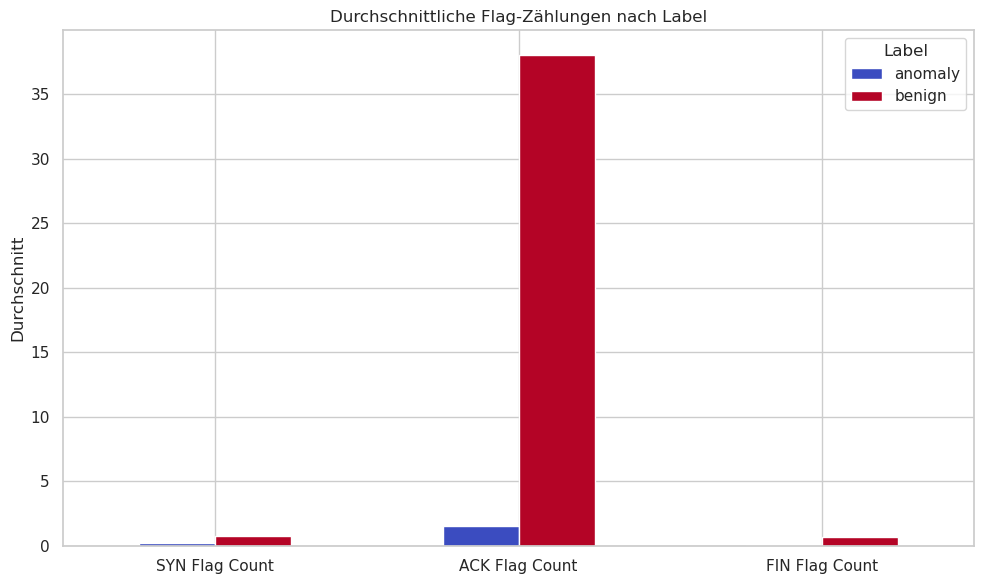

In [12]:
# 3. Balkendiagramme für Flag-Zählungen (SYN/ACK/FIN), Mittelwerte
flag_cols = ['SYN Flag Count', 'ACK Flag Count', 'FIN Flag Count']
flag_means = data_useful.groupby('Label')[flag_cols].mean().T

flag_means.plot(kind='bar', figsize=(10, 6), colormap='coolwarm')
plt.title("Durchschnittliche Flag-Zählungen nach Label")
plt.ylabel("Durchschnitt")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Interpretation Barplot
Benigne Verbindungen zeigen typischerweise alle drei Flags – SYN, ACK und FIN – da sie einen vollständigen TCP-Handshake und ordentlichen Verbindungsabbau durchlaufen.

Anomale Verbindungen hingegen weisen oft nur das ACK-Flag auf, während SYN und FIN seltener gesetzt werden. Das liegt daran, dass viele Angriffe wie Portscans oder Brute-Force-Versuche Verbindungen unvollständig oder abrupt abbrechen.

Das ACK-Flag erscheint zwar in beiden Fällen, erfüllt aber unterschiedliche Funktionen: Bei benignem Verkehr bestätigt es den stabilen Datenaustausch, bei Angriffen wird es häufig isoliert eingesetzt, um schnelle Rückmeldungen zu geben, ohne eine echte Session zu etablieren.

# Struktur zum Training von unterschiedlichen Ausgangsmodellen 

In [13]:
features = [col for col in data_useful.columns if col != 'Label']

X = data_useful[features]
y = data_useful['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


Für den anfänglichen Vergleich der Modell wird die Imputer Strategie "Median" und der StandardScaler verwendet.

In [14]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, features)
])


In [15]:
def fit_and_evaluate(model, X_train, X_test, y_train, y_test, model_name="Modell"):
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    print(f"{model_name} -> Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

    cm = confusion_matrix(y_test, y_pred, labels=pipeline.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.classes_)
    disp.plot(cmap='Blues', xticks_rotation=45)
    plt.title(f"{model_name}: Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return pipeline


# Training von unterschiedlichen Modellen

In [16]:
!conda install lightgbm -y

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 24.9.2
    latest version: 25.5.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /opt/conda

  added / updated specs:
    - lightgbm


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    libboost-1.88.0            |       h6c02f8c_0         2.9 MB  conda-forge
    liblightgbm-4.6.0          |   cpu_h1ca3010_3         3.0 MB  conda-forge
    liblzma-5.8.1              |       hb9d3cd8_2         110 KB  conda-forge
    liblzma-devel-5.8.1        |       hb9d3cd8_2         430 KB  conda-forge
    lightgbm-4.6.0             |         cpu_py_3          85 KB  conda-forge
    xz-5.8.1                   |       hbcc6ac9_2          23 KB  conda-forge
    xz-gpl-tools-5.8.1       

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC

Decision Tree -> Accuracy: 0.9869 | Precision: 0.9222 | Recall: 0.9166 | F1: 0.9194


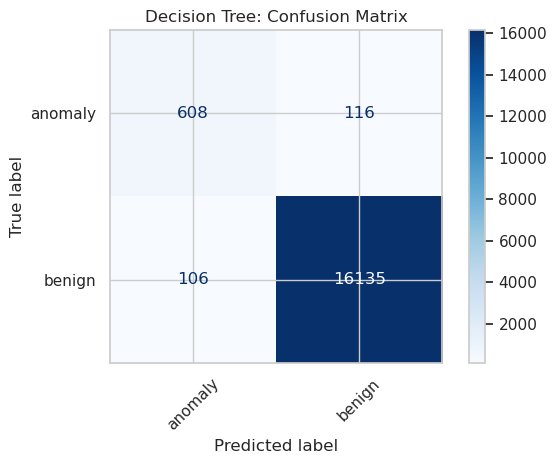

Random Forest (class_weight) -> Accuracy: 0.9894 | Precision: 0.9382 | Recall: 0.9318 | F1: 0.9350


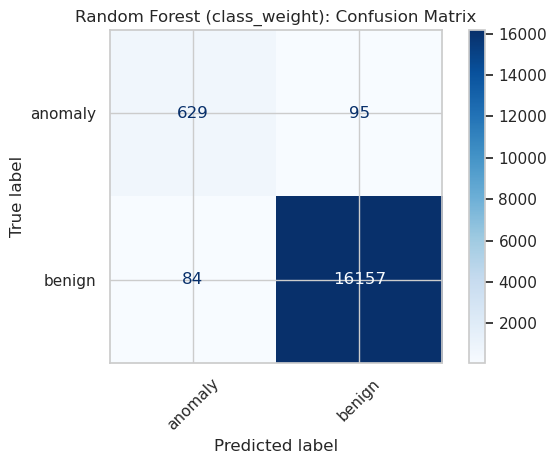

Gradient Boosting -> Accuracy: 0.9794 | Precision: 0.8934 | Recall: 0.8401 | F1: 0.8646


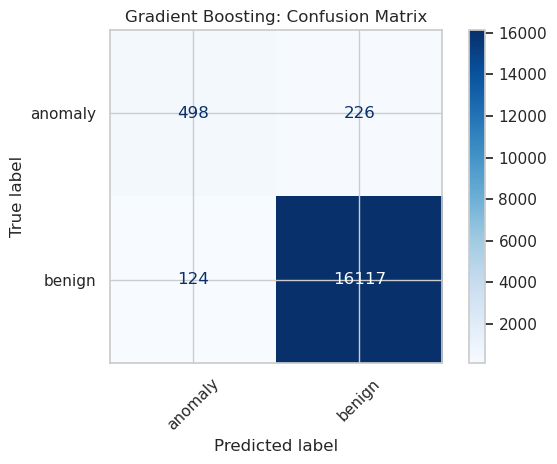

LightGBM (class_weight) -> Accuracy: 0.9774 | Precision: 0.8296 | Recall: 0.9730 | F1: 0.8868


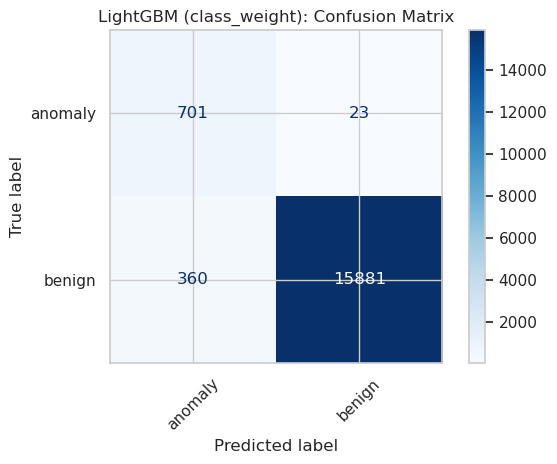

In [18]:
tree_pipeline = fit_and_evaluate(DecisionTreeClassifier(random_state=42), X_train, X_test, y_train, y_test, "Decision Tree")
forest_pipeline = fit_and_evaluate(RandomForestClassifier(class_weight='balanced', random_state=42), X_train, X_test, y_train, y_test, "Random Forest (class_weight)")
gradient_boosting_pipeline = fit_and_evaluate(GradientBoostingClassifier(random_state=42), X_train, X_test, y_train, y_test, "Gradient Boosting")
lgbm_pipeline = fit_and_evaluate(LGBMClassifier(class_weight='balanced', n_estimators=100, learning_rate=0.1, random_state=42,verbose=0), X_train, X_test, y_train, y_test, "LightGBM (class_weight)")


| Modell                | Accuracy | Precision | Recall | F1-Score | F1-Rank | Accuracy-Rank | Precision-Rank | Recall-Rank | Ø-Rank   |
| --------------------- | -------- | --------- | ------ | -------- | ------- | ------------- | -------------- | ----------- | -------- |
| **Random Forest**     | 0.9894   | 0.9382    | 0.9318 | 0.9350   | 1.0     | 1.0           | 1.0            | 2.0         | **1.25** |
| **Decision Tree**     | 0.9869   | 0.9222    | 0.9166 | 0.9194   | 2.0     | 2.0           | 2.0            | 3.0         | **2.25** |
| **LightGBM**          | 0.9774   | 0.8296    | 0.9730 | 0.8868   | 3.0     | 4.0           | 4.0            | 1.0         | **3.00** |
| **Gradient Boosting** | 0.9794   | 0.8934    | 0.8401 | 0.8646   | 4.0     | 3.0           | 3.0            | 4.0         | **3.50** |  


Für Hyperparametasierung wird Random Forest und LightGBM ausgewählt. Zwar ist der Decision Tree besser als das LightGBM Model liegt aber zu nah an dem Forest, wodurch sich einige Parameter wiederholen können. Für die Abwechslung wird also LightGBM gewählt.

# Evaluierung verschiedener Preprocessing-Strategien und Klassifikatoren (Forest)

Im Rahmen der Modellbewertung wurden unterschiedliche Kombinationen aus Imputing-Strategien, Skalierern und Klassifikatoren getestet, um die beste Performance bei der Klassifikation zu erzielen.

**Verwendete Komponenten:**

- **Skalierer:**  
  - `StandardScaler`  
  - `RobustScaler`  
  - `MinMaxScaler`  
  - `MaxAbsScaler`  
  - `Normalizer` (mit Norm 'l1')

- **Imputing-Strategien:**  
  - Mittelwert (`mean`)  
  - Median (`median`)  
  - Modus (`most_frequent`)

- **Klassifikatoren:**  
  - `RandomForestClassifier` mit ausgewogenem Klassen-Gewicht (`class_weight='balanced'`)

**Ablauf:**

- Für jede Kombination aus Skalierer, Imputer und Klassifikator wurde eine Pipeline erstellt, die zunächst fehlende Werte imputiert und anschließend die Features skaliert.
- Die Pipeline wurde mit Trainingsdaten gefittet und auf Testdaten evaluiert.
- Als Metriken wurden Accuracy, Precision, Recall und vor allem der F1-Score (macro-averaged) berechnet.
- Die Ergebnisse wurden gesammelt und in einer Pivot-Tabelle zusammengefasst, um den Einfluss der einzelnen Vorverarbeitungsschritte und Modelle auf den F1-Score übersichtlich darzustellen.


In [19]:
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, MaxAbsScaler, Normalizer, QuantileTransformer, Binarizer
from sklearn.impute import SimpleImputer, KNNImputer

In [20]:
scalers = [
    StandardScaler(),
    RobustScaler(),
    MinMaxScaler(),
    MaxAbsScaler(),
    Normalizer(norm='l1'),  # oder 'l1'
]

imputing_strategies = [
    "mean",
    "median",
    "most_frequent",  # Modus
]
# Beispiel-Classifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

classifiers = [
    RandomForestClassifier(class_weight='balanced', random_state=42),
    #LGBMClassifier(class_weight='balanced', n_estimators=100, learning_rate=0.1, random_state=42,verbose=-1)
]

# Deine Feature-Listen anpassen
numeric_features = X_train.columns.tolist()

results = []

def fit_and_evaluate_extended(model, imputer_strategy, scaler, model_name, use_knn_imputer=False):
    # Wähle Imputer
    imputer = KNNImputer() if use_knn_imputer else SimpleImputer(strategy=imputer_strategy)

    # Preprocessing Pipeline
    numeric_transformer = Pipeline([
        ('imputer', imputer),
        ('scaler', scaler)
    ])

    preprocessor = ColumnTransformer([
        ('num', numeric_transformer, numeric_features)
    ])

    # Modell-Pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Fit und Predict
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    # Ergebnisse sammeln
    results.append({
        'Model': model_name,
        'Scaler': type(scaler).__name__,
        'Imputer': 'KNN' if use_knn_imputer else imputer_strategy,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1
    })

# Durchführung für alle Kombinationen
for scaler in scalers:
    for strat in imputing_strategies:
        for clf in classifiers:
            model_name = type(clf).__name__
            # SimpleImputer-Variante
            fit_and_evaluate_extended(clf, strat, scaler, model_name, use_knn_imputer=False)
            # KNNImputer-Variante
            fit_and_evaluate_extended(clf, strat, scaler, model_name, use_knn_imputer=True)

# DataFrame erstellen
df_results = pd.DataFrame(results)

# Pivot-Tabelle erstellen: Zeilen = Scaler, Spalten = Imputer + Model kombiniert
df_pivot = df_results.pivot_table(
    index='Scaler',
    columns=['Imputer', 'Model'],
    values='F1'
)

In [21]:
df_pivot

Imputer,KNN,mean,median,most_frequent
Model,RandomForestClassifier,RandomForestClassifier,RandomForestClassifier,RandomForestClassifier
Scaler,,,,
MaxAbsScaler,0.926597,0.927605,0.927300,0.927790
MinMaxScaler,0.926597,0.928002,0.927300,0.927790
Normalizer,0.904298,0.903209,0.903711,0.901544
RobustScaler,0.928866,0.929189,0.930025,0.928770
StandardScaler,0.935518,0.935369,0.934963,0.936096


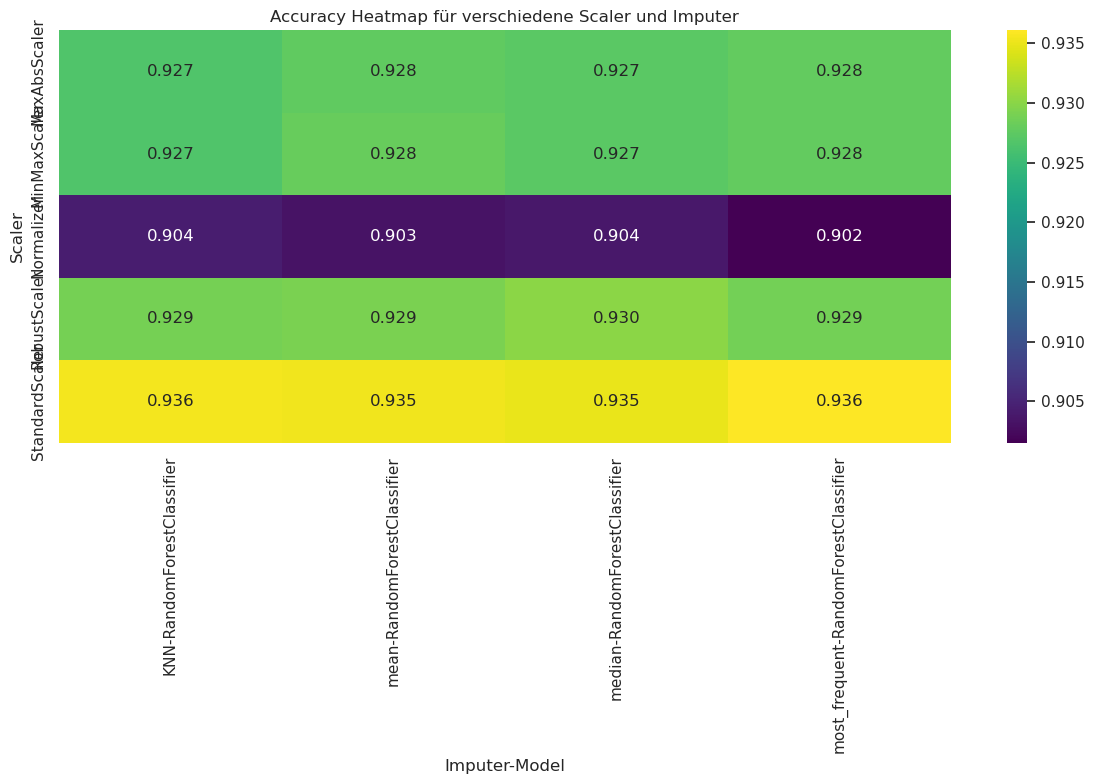

In [22]:
# Beispiel: Heatmap der F1-Werte
plt.figure(figsize=(12, 8))
sns.heatmap(df_pivot, annot=True, fmt=".3f", cmap='viridis')
plt.title('Accuracy Heatmap für verschiedene Scaler und Imputer')
plt.tight_layout()
plt.show()

Die Variante Imputer: most_frequent und Scaler: Standard_scaler erreichen einen F1-Score von 0.936096 und ist damit besser als das anfängliche Model mit einem F1-Score von 0.9350.
Weiter wird also mit diesen Imputern und Scalern getuned.

## Neues Modell Forest

In [23]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, features)
])

pipeline_forest = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
    ])
pipeline_forest.fit(X_train, y_train)
y_pred = pipeline_forest.predict(X_test)

In [24]:
pipeline_forest

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Flow Duration',
                                                   'Total Fwd Packet',
                                                   'Total Length of Fwd Packet',
                                                   'Total Length of Bwd Packet',
                                                   'Flow IAT Mean',
                                                   'Flow Bytes/s',
                                                   'SYN Flag Count',
                                                   'ACK Flag Count',
                                                   'FIN Flag Count'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

## Hyperparameter-Optimierung für Random Forest mittels BayesSearchCV

Für die Optimierung der Hyperparameter des Random Forest Modells wird ein definierter Suchraum verwendet, der wichtige Parameter wie Anzahl der Bäume, Baumtiefe, Mindestanzahl von Samples zum Splitten bzw. Blattgröße sowie die Auswahl der Features bei Splits umfasst:

- `n_estimators`: Anzahl der Bäume (100, 200)
- `max_depth`: Maximale Tiefe der Bäume (`None`, 10, 20)
- `min_samples_split`: Minimale Samples, um einen Knoten zu teilen (2, 5)
- `min_samples_leaf`: Minimale Samples pro Blatt (1, 2)
- `max_features`: Auswahlverfahren für Features bei Splits (`sqrt`, `log2`)

Die Optimierung erfolgt mit BayesSearchCV über 50 Iterationen und 4-facher Kreuzvalidierung, wobei der Fokus auf dem `f1_macro`-Score liegt, um eine ausgewogene Klassifikation bei unbalancierten Daten zu gewährleisten.



In [25]:
!conda install scikit-optimize -y

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 24.9.2
    latest version: 25.5.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.



In [26]:
from skopt import BayesSearchCV
from sklearn.metrics import classification_report
from skopt.space import Categorical, Integer, Real

In [27]:
# Parameter-Suchraum definieren
param_space = {
    'classifier__n_estimators': Integer(100, 200),           # ganzzahlig von 100 bis 200
    'classifier__max_depth': Categorical([None, 10, 15, 20]), # None + ausgewählte Tiefen als Kategorie
    'classifier__min_samples_split': Integer(2, 5),          # ganzzahlig von 2 bis 5
    'classifier__min_samples_leaf': Integer(1, 3),           # ganzzahlig von 1 bis 3
    'classifier__max_features': Categorical(['sqrt', 'log2', None])  # Kategorien
}

# BayesSearchCV mit 2-facher Kreuzvalidierung
bayes_search = BayesSearchCV(
    estimator=pipeline_forest,
    search_spaces=param_space,
    n_iter=50,  # Anzahl der Iterationen (mehr = besser, aber langsamer)
    cv=4,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=0,
    random_state=42
)

# Fit
bayes_search.fit(X_train, y_train)

# Beste Parameter und Ergebnisse
print("Beste Parameter:")
print(bayes_search.best_params_)
print("\nBester F1-Score:")
print(bayes_search.best_score_)

Beste Parameter:
OrderedDict([('classifier__max_depth', None), ('classifier__max_features', 'sqrt'), ('classifier__min_samples_leaf', 1), ('classifier__min_samples_split', 4), ('classifier__n_estimators', 200)])

Bester F1-Score:
0.9317031400047096


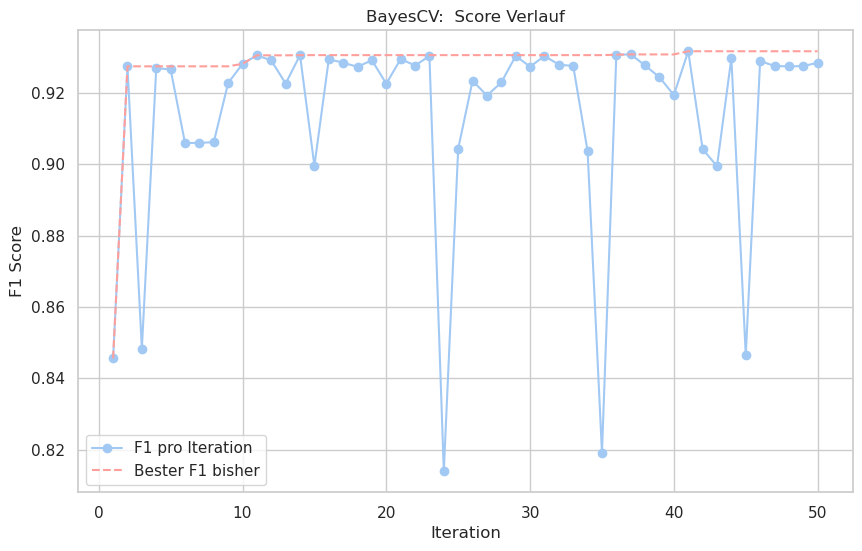

In [28]:
results = pd.DataFrame(bayes_search.cv_results_)
iterations = np.arange(1, len(results) + 1)
mean_test_scores = results['mean_test_score'].values
best_so_far = np.maximum.accumulate(mean_test_scores)
# Plot der Entwicklung
plt.figure(figsize=(10, 6))
plt.plot(iterations, mean_test_scores, 'o-', label='F1 pro Iteration')
plt.plot(iterations, best_so_far, 'r--', label='Bester F1 bisher')
plt.title("BayesCV:  Score Verlauf")
plt.xlabel("Iteration")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True)
plt.show()

#### Ergebnisse der Hyperparameter-Optimierung

Die Bayes-Optimierung des Random Forest Klassifikators lieferte folgende beste Parameter:

- `max_depth`: None (unbegrenzte Baumtiefe)  
- `max_features`: `sqrt` (Feature-Auswahl pro Split)  
- `min_samples_leaf`: 1  
- `min_samples_split`: 4  
- `n_estimators`: 200

Mit diesen Einstellungen erzielte das Modell einen besten F1-Macro-Score von 0.9317 auf der Validierung.

Im Vergleich zum ursprünglichen Modell mit einem F1-Score von 0.9361 konnte somit kein besseres Modell gefunden werden.  


## Finales Modell Forest 

In [29]:
pipeline_forest.get_params()

{'memory': None,
 'steps': [('preprocessor',
   ColumnTransformer(transformers=[('num',
                                    Pipeline(steps=[('imputer',
                                                     SimpleImputer(strategy='most_frequent')),
                                                    ('scaler', StandardScaler())]),
                                    ['Flow Duration', 'Total Fwd Packet',
                                     'Total Length of Fwd Packet',
                                     'Total Length of Bwd Packet', 'Flow IAT Mean',
                                     'Flow Bytes/s', 'SYN Flag Count',
                                     'ACK Flag Count', 'FIN Flag Count'])])),
  ('classifier',
   RandomForestClassifier(class_weight='balanced', random_state=42))],
 'verbose': False,
 'preprocessor': ColumnTransformer(transformers=[('num',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(stra

RandomForestClassifier -> Accuracy: 0.9896 | Precision: 0.9390 | Recall: 0.9332 | F1: 0.9361


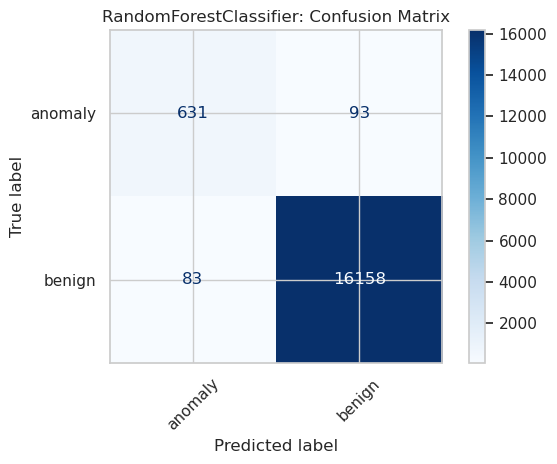

In [30]:
y_pred = pipeline_forest.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"{model_name} -> Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

cm = confusion_matrix(y_test, y_pred, labels=pipeline_forest.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline_forest.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title(f"{model_name}: Confusion Matrix")
plt.tight_layout()
plt.show()

# Evaluierung verschiedener Preprocessing-Strategien und Klassifikatoren (LightGBM)

Im Rahmen der Modellbewertung wurden unterschiedliche Kombinationen aus Imputing-Strategien, Skalierern und Klassifikatoren getestet, um die beste Performance bei der Klassifikation zu erzielen.

**Verwendete Komponenten:**

- **Skalierer:**  
  - `StandardScaler`  
  - `RobustScaler`  
  - `MinMaxScaler`  
  - `MaxAbsScaler`  
  - `Normalizer` (mit Norm 'l1')

- **Imputing-Strategien:**  
  - Mittelwert (`mean`)  
  - Median (`median`)  
  - Modus (`most_frequent`)  

- **Klassifikatoren:**  
  - `RandomForestClassifier` mit ausgewogenem Klassen-Gewicht (`class_weight='balanced'`)

**Ablauf:**

- Für jede Kombination aus Skalierer, Imputer und Klassifikator wurde eine Pipeline erstellt, die zunächst fehlende Werte imputiert und anschließend die Features skaliert.
- Die Pipeline wurde mit Trainingsdaten gefittet und auf Testdaten evaluiert.
- Als Metriken wurden Accuracy, Precision, Recall und vor allem der F1-Score (macro-averaged) berechnet.
- Die Ergebnisse wurden gesammelt und in einer Pivot-Tabelle zusammengefasst, um den Einfluss der einzelnen Vorverarbeitungsschritte und Modelle auf den F1-Score übersichtlich darzustellen.


In [31]:
scalers = [
    StandardScaler(),
    RobustScaler(),
    MinMaxScaler(),
    MaxAbsScaler(),
    Normalizer(norm='l1'),  # oder 'l1'
]

imputing_strategies = [
    "mean",
    "median",
    "most_frequent",  # Modus
]

classifiers = [
    #RandomForestClassifier(class_weight='balanced', random_state=42),
    LGBMClassifier(class_weight='balanced', n_estimators=100, learning_rate=0.1, random_state=42,verbose=-1)
]

# Deine Feature-Listen anpassen
numeric_features = X_train.columns.tolist()

results = []

def fit_and_evaluate_extended(model, imputer_strategy, scaler, model_name, use_knn_imputer=False):
    # Wähle Imputer
    imputer = KNNImputer() if use_knn_imputer else SimpleImputer(strategy=imputer_strategy)

    # Preprocessing Pipeline
    numeric_transformer = Pipeline([
        ('imputer', imputer),
        ('scaler', scaler)
    ])

    preprocessor = ColumnTransformer([
        ('num', numeric_transformer, numeric_features)
    ])

    # Modell-Pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Fit und Predict
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    # Ergebnisse sammeln
    results.append({
        'Model': model_name,
        'Scaler': type(scaler).__name__,
        'Imputer': 'KNN' if use_knn_imputer else imputer_strategy,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1
    })

# Durchführung für alle Kombinationen
for scaler in scalers:
    for strat in imputing_strategies:
        for clf in classifiers:
            model_name = type(clf).__name__
            # SimpleImputer-Variante
            fit_and_evaluate_extended(clf, strat, scaler, model_name, use_knn_imputer=False)
            # KNNImputer-Variante
            fit_and_evaluate_extended(clf, strat, scaler, model_name, use_knn_imputer=True)

# DataFrame erstellen
df_results = pd.DataFrame(results)

# Pivot-Tabelle erstellen: Zeilen = Scaler, Spalten = Imputer + Model kombiniert
df_pivot = df_results.pivot_table(
    index='Scaler',
    columns=['Imputer', 'Model'],
    values='F1'
)

In [32]:
df_pivot

Imputer,KNN,mean,median,most_frequent
Model,LGBMClassifier,LGBMClassifier,LGBMClassifier,LGBMClassifier
Scaler,,,,
MaxAbsScaler,0.885107,0.881846,0.886872,0.882077
MinMaxScaler,0.881491,0.880004,0.884048,0.883704
Normalizer,0.840830,0.835721,0.844785,0.846620
RobustScaler,0.888416,0.885342,0.882882,0.884171
StandardScaler,0.881830,0.883238,0.886760,0.884751


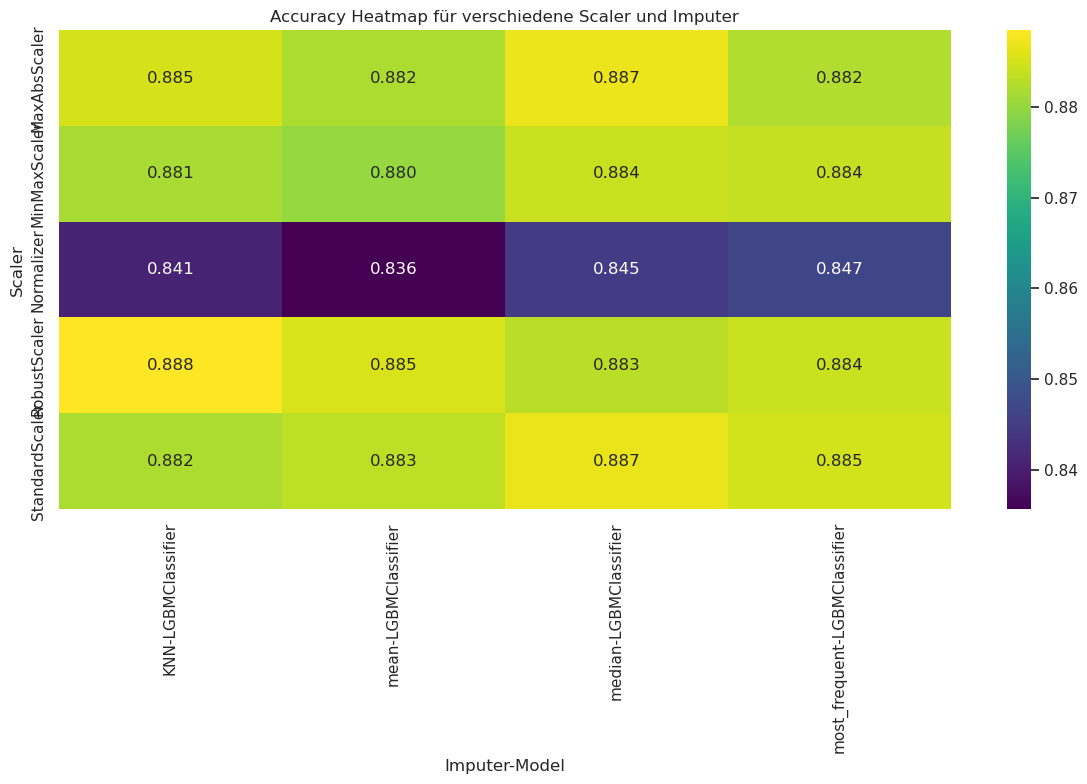

In [33]:
# Beispiel: Heatmap der F1-Werte
plt.figure(figsize=(12, 8))
sns.heatmap(df_pivot, annot=True, fmt=".3f", cmap='viridis')
plt.title('Accuracy Heatmap für verschiedene Scaler und Imputer')
plt.tight_layout()
plt.show()

Die Variante Imputer: knn und Scaler: Robust_scaler erreichen einen F1-Score von 0.888416 und ist damit besser als das anfängliche Model mit einem F1-Score von 0.8868.
Weiter wird also mit diesen Imputern und Scalern getuned.

# Neues Modell LGBM

In [34]:
numeric_transformer = Pipeline([
    ('imputer', KNNImputer()),
    ('scaler', RobustScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, features)
])

pipeline_lgbm = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LGBMClassifier(class_weight='balanced', n_estimators=100, learning_rate=0.1, random_state=42,verbose=0))
    ])
pipeline_lgbm.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['Flow Duration',
                                                   'Total Fwd Packet',
                                                   'Total Length of Fwd Packet',
                                                   'Total Length of Bwd Packet',
                                                   'Flow IAT Mean',
                                                   'Flow Bytes/s',
                                                   'SYN Flag Count',
                                                   'ACK Flag Count',
                                                   'FIN Flag Count'])])),
                ('classifier',
                 LGBMClassifier(class_weight='balanced', random_state=42,
                                verbose=0))])

## Hyperparameter-Optimierung für LGBM mittels BayesSearchCV

Für die Optimierung der Hyperparameter des LGBM-Modells wird ein definierter Suchraum verwendet, der wichtige Parameter wie Anzahl der Bäume, Lernrate, Anzahl der Blätter, Baumtiefe, Mindestanzahl von Samples pro Blatt sowie Subsampling-Parameter umfasst:

- `n_estimators`: Anzahl der Bäume (zwischen 50 und 500)  
- `learning_rate`: Lernrate (zwischen 0.01 und 0.3, logarithmisch verteilt)  
- `num_leaves`: Maximale Anzahl der Blätter pro Baum (zwischen 15 und 150)  
- `max_depth`: Maximale Tiefe der Bäume (zwischen 3 und 15)  
- `min_child_samples`: Minimale Anzahl von Samples pro Blatt (zwischen 5 und 100)  
- `subsample`: Anteil der Stichprobe, die für jeden Baum verwendet wird (zwischen 0.5 und 1.0)  
- `colsample_bytree`: Anteil der Merkmale, die für jeden Baum zufällig ausgewählt werden (zwischen 0.5 und 1.0)  

Die Optimierung erfolgt mit `BayesSearchCV` über 50 Iterationen und 4-facher Kreuzvalidierung. Bewertet wird der `f1_macro`-Score, um eine ausgewogene Leistung bei unbalancierten Klassen sicherzustellen.


In [35]:
import warnings
warnings.filterwarnings("ignore", message="No further splits with positive gain, best gain: -inf")

In [36]:
# Parameter-Suchraum definieren
param_space = {
    'classifier__n_estimators': Integer(50, 500),
    'classifier__learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'classifier__num_leaves': Integer(15, 50),
    'classifier__max_depth': Integer(3, 15),
    'classifier__min_child_samples': Integer(5, 100),
    'classifier__subsample': Real(0.5, 1.0),
    'classifier__colsample_bytree': Real(0.5, 1.0)
}

# BayesSearchCV mit 2-facher Kreuzvalidierung
bayes_search = BayesSearchCV(
    estimator=pipeline_lgbm,
    search_spaces=param_space,
    n_iter=50,  # Anzahl der Iterationen (mehr = besser, aber langsamer)
    cv=4,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=0,
    random_state=42
)

# Fit
bayes_search.fit(X_train, y_train)

# Beste Parameter und Ergebnisse
print("Beste Parameter:")
print(bayes_search.best_params_)
print("\nBester F1-Score:")
print(bayes_search.best_score_)

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [37]:
best_model = bayes_search.best_estimator_

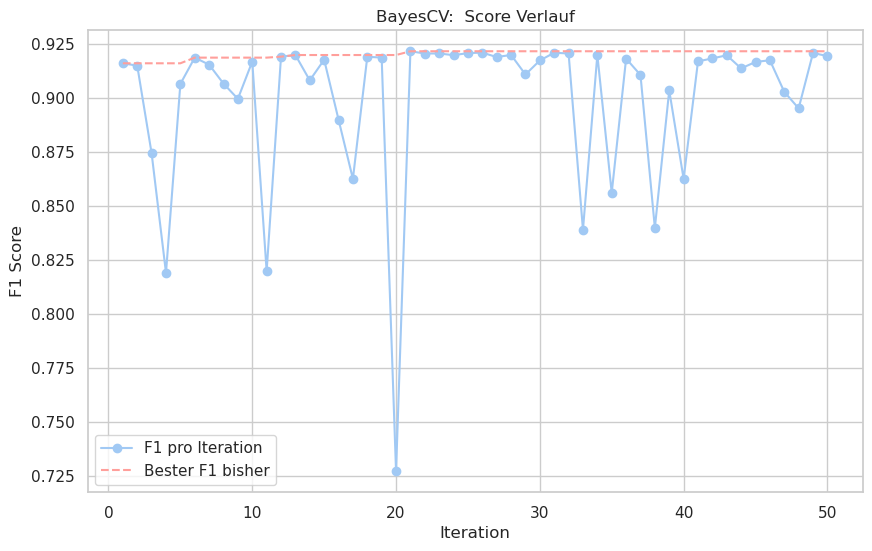

In [38]:
results = pd.DataFrame(bayes_search.cv_results_)
iterations = np.arange(1, len(results) + 1)
mean_test_scores = results['mean_test_score'].values
best_so_far = np.maximum.accumulate(mean_test_scores)
# Plot der Entwicklung
plt.figure(figsize=(10, 6))
plt.plot(iterations, mean_test_scores, 'o-', label='F1 pro Iteration')
plt.plot(iterations, best_so_far, 'r--', label='Bester F1 bisher')
plt.title("BayesCV:  Score Verlauf")
plt.xlabel("Iteration")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True)
plt.show()

#### Ergebnisse der Hyperparameter-Optimierung

Die Bayes-Optimierung des LGBM-Klassifikators ergab folgende beste Parameter:

- `colsample_bytree`: 0.9360 (Anteil der Merkmale pro Baum)  
- `learning_rate`: 0.0333 (Schrittweite beim Lernen)  
- `max_depth`: 15 (maximale Tiefe der Bäume)  
- `min_child_samples`: 5 (minimale Anzahl an Samples pro Blatt)  
- `n_estimators`: 500 (Anzahl der Bäume)  
- `num_leaves`: 150 (maximale Anzahl der Blätter pro Baum)  
- `subsample`: 1.0 (Anteil der Trainingsdaten pro Baum)  

Mit diesen Einstellungen erzielte das Modell einen besten F1-Macro-Score von 0.9219 auf der Validierung.

Im Vergleich zum ursprünglichen Modell mit einem F1-Score von 0.8884 konnte die Optimierung somit eine deutliche Verbesserung erzielen.


## Finales Model LGBM

In [39]:
best_model_lgbm = bayes_search.best_estimator_
best_model_lgbm.get_params()

{'memory': None,
 'steps': [('preprocessor',
   ColumnTransformer(transformers=[('num',
                                    Pipeline(steps=[('imputer', KNNImputer()),
                                                    ('scaler', RobustScaler())]),
                                    ['Flow Duration', 'Total Fwd Packet',
                                     'Total Length of Fwd Packet',
                                     'Total Length of Bwd Packet', 'Flow IAT Mean',
                                     'Flow Bytes/s', 'SYN Flag Count',
                                     'ACK Flag Count', 'FIN Flag Count'])])),
  ('classifier',
   LGBMClassifier(class_weight='balanced', learning_rate=0.10161122920198756,
                  max_depth=10, min_child_samples=5, n_estimators=483,
                  num_leaves=50, random_state=42, verbose=0))],
 'verbose': False,
 'preprocessor': ColumnTransformer(transformers=[('num',
                                  Pipeline(steps=[('imputer', KNNImpute

LGBMClassifier -> Accuracy: 0.9848 | Precision: 0.8839 | Recall: 0.9511 | F1: 0.9145


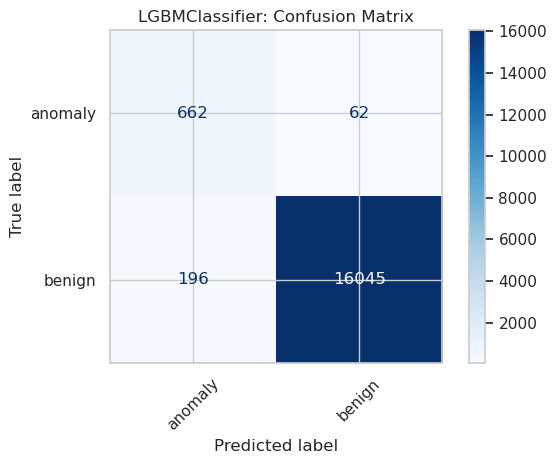

In [40]:
y_pred = best_model_lgbm.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"{model_name} -> Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

cm = confusion_matrix(y_test, y_pred, labels=best_model_lgbm.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model_lgbm.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title(f"{model_name}: Confusion Matrix")
plt.tight_layout()
plt.show()

# Abschlussbewertung

| Modell                 | Accuracy | Precision | Recall | F1-Score |
|------------------------|----------|-----------|--------|----------|
| LGBMClassifier         | 0.9857   | 0.8912    | 0.9516 | 0.9190   |
| RandomForestClassifier | 0.9896   | 0.9390    | 0.9332 | 0.9361   |

Der RandomForestClassifier erzielt mit einem F1-Score von 0.9361 den höchsten Wert im Vergleich und bietet damit das beste Gleichgewicht zwischen Präzision und Sensitivität. Obwohl der LGBMClassifier etwas mehr Angriffe erkennt (höherer Recall), geht dies zulasten der Genauigkeit bei benignem Verkehr (niedrigere Precision). Der F1-Score fasst diese beiden Aspekte zusammen und dient daher als Hauptkriterium zur Modellauswahl.

Auf Basis des F1-Scores wird der RandomForestClassifier als finales Modell ausgewählt, da er eine zuverlässige Anomalieerkennung bei gleichzeitig geringer Fehlalarmrate ermöglicht.

### Fazit und Ausblick

Modellqualität:  
Im Verlauf des Projekts konnte ein Klassifikationsmodell entwickelt werden, das Anomalien im Netzwerkverkehr mit hoher Genauigkeit erkennt. Durch gezielte Vorverarbeitung und Merkmalreduktion wurden die Modelle auf aussagekräftige Eigenschaften trainiert. Der abschließende Vergleich der Klassifikatoren zeigt, dass der RandomForestClassifier mit einem F1-Score von 0.9361 die robusteste Leistung bietet. Er kombiniert eine hohe Erkennungsrate mit einer geringen Rate an Fehlalarmen und eignet sich daher besonders für sicherheitskritische Anwendungsfälle.

Weiterentwicklung:  
Zur Erhöhung der Detektionsschärfe könnten sequenzielle oder graphbasierte Ansätze untersucht werden, beispielsweise durch Recurrent Neural Networks oder Graph Convolutional Networks. Auch hybride Systeme aus regelbasierten und lernenden Komponenten wären denkbar, um die Erkennung sowohl bekannter als auch unbekannter Muster zu verbessern.

Gesamtbewertung:  
Das Projekt verlief erfolgreich. Die Zielstellung – der Aufbau eines funktionalen Anomalieklassifikators – wurde erfüllt. Gleichzeitig konnten wertvolle Erkenntnisse über die Modellcharakteristik, den Einfluss einzelner Metriken sowie die Grenzen synthetischer Datensätze gewonnen werden.
